# Load Skeletons

### Imports

In [1]:
import json
import numpy as np
import os
import sys

from agentic_neuron_proofreader.utils import img_util, util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# Shared dataset-config helpers (segmentation-id lookup, image path).
sys.path.insert(0, "../scripts")
from dataset_config import get_segmentation_id, get_img_path

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

### Subroutines

`get_segmentation_id` (brain_id → segmentation_id, from
`configs/segmentation_datasets.rtf`) and `get_img_path` (brain_id → ExaSPIM
image path) now live in [`scripts/dataset_config.py`](../scripts/dataset_config.py)
so other notebooks can reuse them; they were imported in the cell above.

## Section 1: Load Data

### Initializations

In [2]:
# Dataset info
brain_id = "794492"
# Segmentation id is looked up from configs/segmentation_datasets.rtf by brain_id,
# so switching brains only requires changing brain_id above.
segmentation_id = get_segmentation_id(brain_id)
print(f"brain_id={brain_id} -> segmentation_id={segmentation_id}")

# Paths
gt_path = f"gs://allen-nd-goog/ground_truth_tracings/{brain_id}/voxel"
fragments_path = f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/swcs"

img_path = get_img_path(brain_id)
segmentation_path =  f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/"

brain_id=794492 -> segmentation_id=denoised.unet_r3_ckpt_155250


### Load Data

In [3]:
# Parameters
# anisotropy: voxel-to-physical scaling factors in microns/voxel for (x, y, z).
#   ExaSPIM samples xy more finely than z, so voxels are not cubic. Used to
#   convert SWC coordinates (microns) <-> image voxel indices when reading patches.
anisotropy = (0.748, 0.748, 1.0)

# min_cable_length: drop fragments whose total skeleton path length (in microns)
#   is below this threshold. Filters out short, noisy UNet fragments at load time.
min_cable_length = 100

# node_spacing: target distance (in microns) between neighboring nodes after
#   resampling each skeleton branch. Lower = finer geometry but more memory.
node_spacing = 5

# Create dataset
dataset = BrainDataset(
    fragments_path,
    gt_path,
    img_path,
    anisotropy=anisotropy,
    min_cable_length=min_cable_length,
    node_spacing=node_spacing,
)

# Report summary
print(dataset.fragments_graph.summary(prefix="Fragments"))
print(dataset.gt_graph.summary(prefix="GroundTruth"))

Load Graphs: 100%|██████████| 53/53 [08:08<00:00,  9.21s/it]


Fragments Graph
# Connected Components: 209,615
# Nodes: 15,097,392
# Edges: 14,887,777
Memory Consumption: 33.05 GBs
GroundTruth Graph
# Connected Components: 53
# Nodes: 3,774,885
# Edges: 3,774,832
Memory Consumption: 33.06 GBs


### Save Dataset Cache

Pickles the two `SkeletonGraph` objects (the slow part to rebuild — ~15 min from GCS) plus the paths/parameters needed to re-open the lazy image readers. The `TensorStoreImage` itself is NOT pickled because it re-instantiates instantly.

Expected cache size is ~500–700 MB (mostly NetworkX adjacency + KDTree + a few NumPy arrays). This is much smaller than the "Memory Consumption" line in `summary()`, which reports total *process* memory (TensorStore caches, the SWC reader pool, etc.) rather than the graph's own footprint.

Use `load_skeletons_from_cache.ipynb` to reload without re-reading the SWCs.

In [4]:
# Save caches into the dedicated ../cache/ folder. Encode min_cable_length in the
# filename so caches built with different fragment-filtering thresholds don't
# overwrite one another.
cache_dir = "../cache"
os.makedirs(cache_dir, exist_ok=True)
cache_path = os.path.join(cache_dir, f"dataset_cache_{brain_id}_mcl{min_cable_length}.pkl")
dataset.save(cache_path)
print(f"Saved dataset cache: {cache_path} ({os.path.getsize(cache_path) / 1e9:.2f} GB)")

Saved dataset cache: ../cache/dataset_cache_794492_mcl100.pkl (2.02 GB)


### Visualization

In [5]:
segmentation = img_util.TensorStoreImage(segmentation_path)

I0609 16:43:16.243021 2149466 google_auth_provider.cc:149] Using credentials at ../configs/zihan_gcs_token.json
I0609 16:43:16.249645 2149466 google_auth_provider.cc:165] Using ServiceAccount AuthProvider


3774885


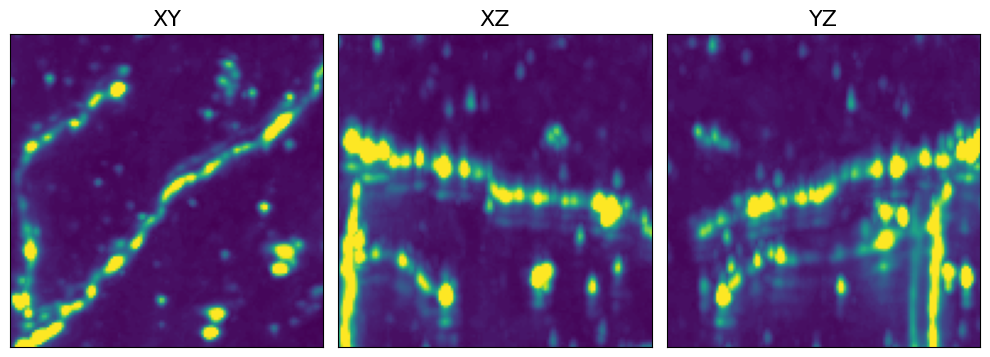

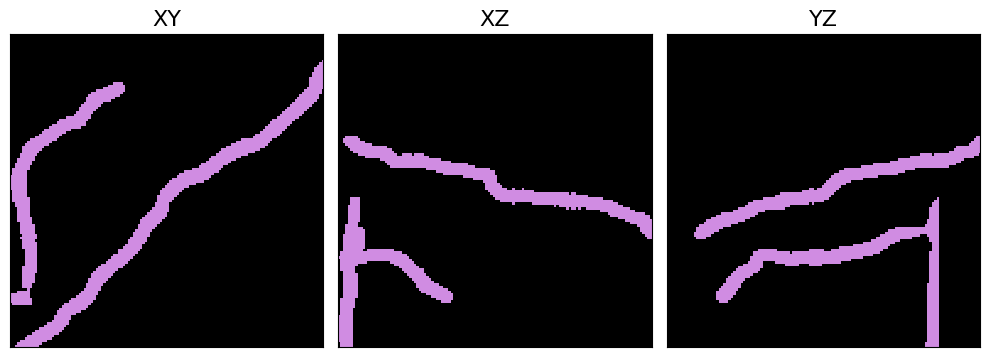

In [6]:
# Parameters
# patch_shape: size of the (z, y, x) voxel cube to read around the sampled center.
patch_shape = (128, 128, 128)

# use_groundtruth: chooses WHICH skeleton graph to randomly sample a center voxel
#   from. It does NOT control what gets plotted -- both figures below always show
#   the raw image and the UNet segmentation.
#     True  -> center on a human-traced (GT) node => patch is guaranteed to
#              contain a real neurite. Good for asking "did the UNet correctly
#              segment a real neuron here?"
#     False -> center on a UNet fragment node => patch is wherever the model
#              flagged a >= min_cable_length fragment. Good for asking "is this
#              UNet fragment real or a false positive?"
use_groundtruth = True

print(len(dataset.gt_graph.nodes))

# Sample a single random node from the chosen graph and convert it to a voxel
# coordinate. This voxel is just the *center* of the patch; the GT/fragment
# graph only contributes a location, not pixels.
if use_groundtruth:
    node = util.sample_once(dataset.gt_graph.nodes)
    voxel = dataset.gt_graph.node_voxel(node)
else:
    node = util.sample_once(dataset.fragments_graph.nodes)
    voxel = dataset.fragments_graph.node_voxel(node)

# Read aligned patches at the same center.
#   img_patch          -- raw ExaSPIM fluorescence (dataset.img)
#   segmentation_patch -- UNet predicted label volume (segmentation_path,
#                         i.e. raw.unet_449_splits_and_merges_900000)
img_patch = dataset.img.read(voxel, patch_shape)
segmentation_patch = segmentation.read(voxel, patch_shape)

# Plot MIPs. Note: plot_segmentation_mips ALWAYS shows the UNet mask -- there
# is no dense ground-truth volume in this dataset (GT is skeleton-only and
# lives in dataset.gt_graph). To see GT, look at the skeleton-MIP cell below.
img_util.plot_mips(img_patch)
img_util.plot_segmentation_mips((segmentation_patch > 0).astype(int))